In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

In [ ]:
df = pd.read_csv('online_shoppers_intention.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

array([[<Axes: title={'center': 'Administrative'}>,
        <Axes: title={'center': 'Administrative_Duration'}>,
        <Axes: title={'center': 'Informational'}>,
        <Axes: title={'center': 'Informational_Duration'}>],
       [<Axes: title={'center': 'ProductRelated'}>,
        <Axes: title={'center': 'ProductRelated_Duration'}>,
        <Axes: title={'center': 'BounceRates'}>,
        <Axes: title={'center': 'ExitRates'}>],
       [<Axes: title={'center': 'PageValues'}>,
        <Axes: title={'center': 'SpecialDay'}>,
        <Axes: title={'center': 'OperatingSystems'}>,
        <Axes: title={'center': 'Browser'}>],
       [<Axes: title={'center': 'Region'}>,
        <Axes: title={'center': 'TrafficType'}>, <Axes: >, <Axes: >]],
      dtype=object)

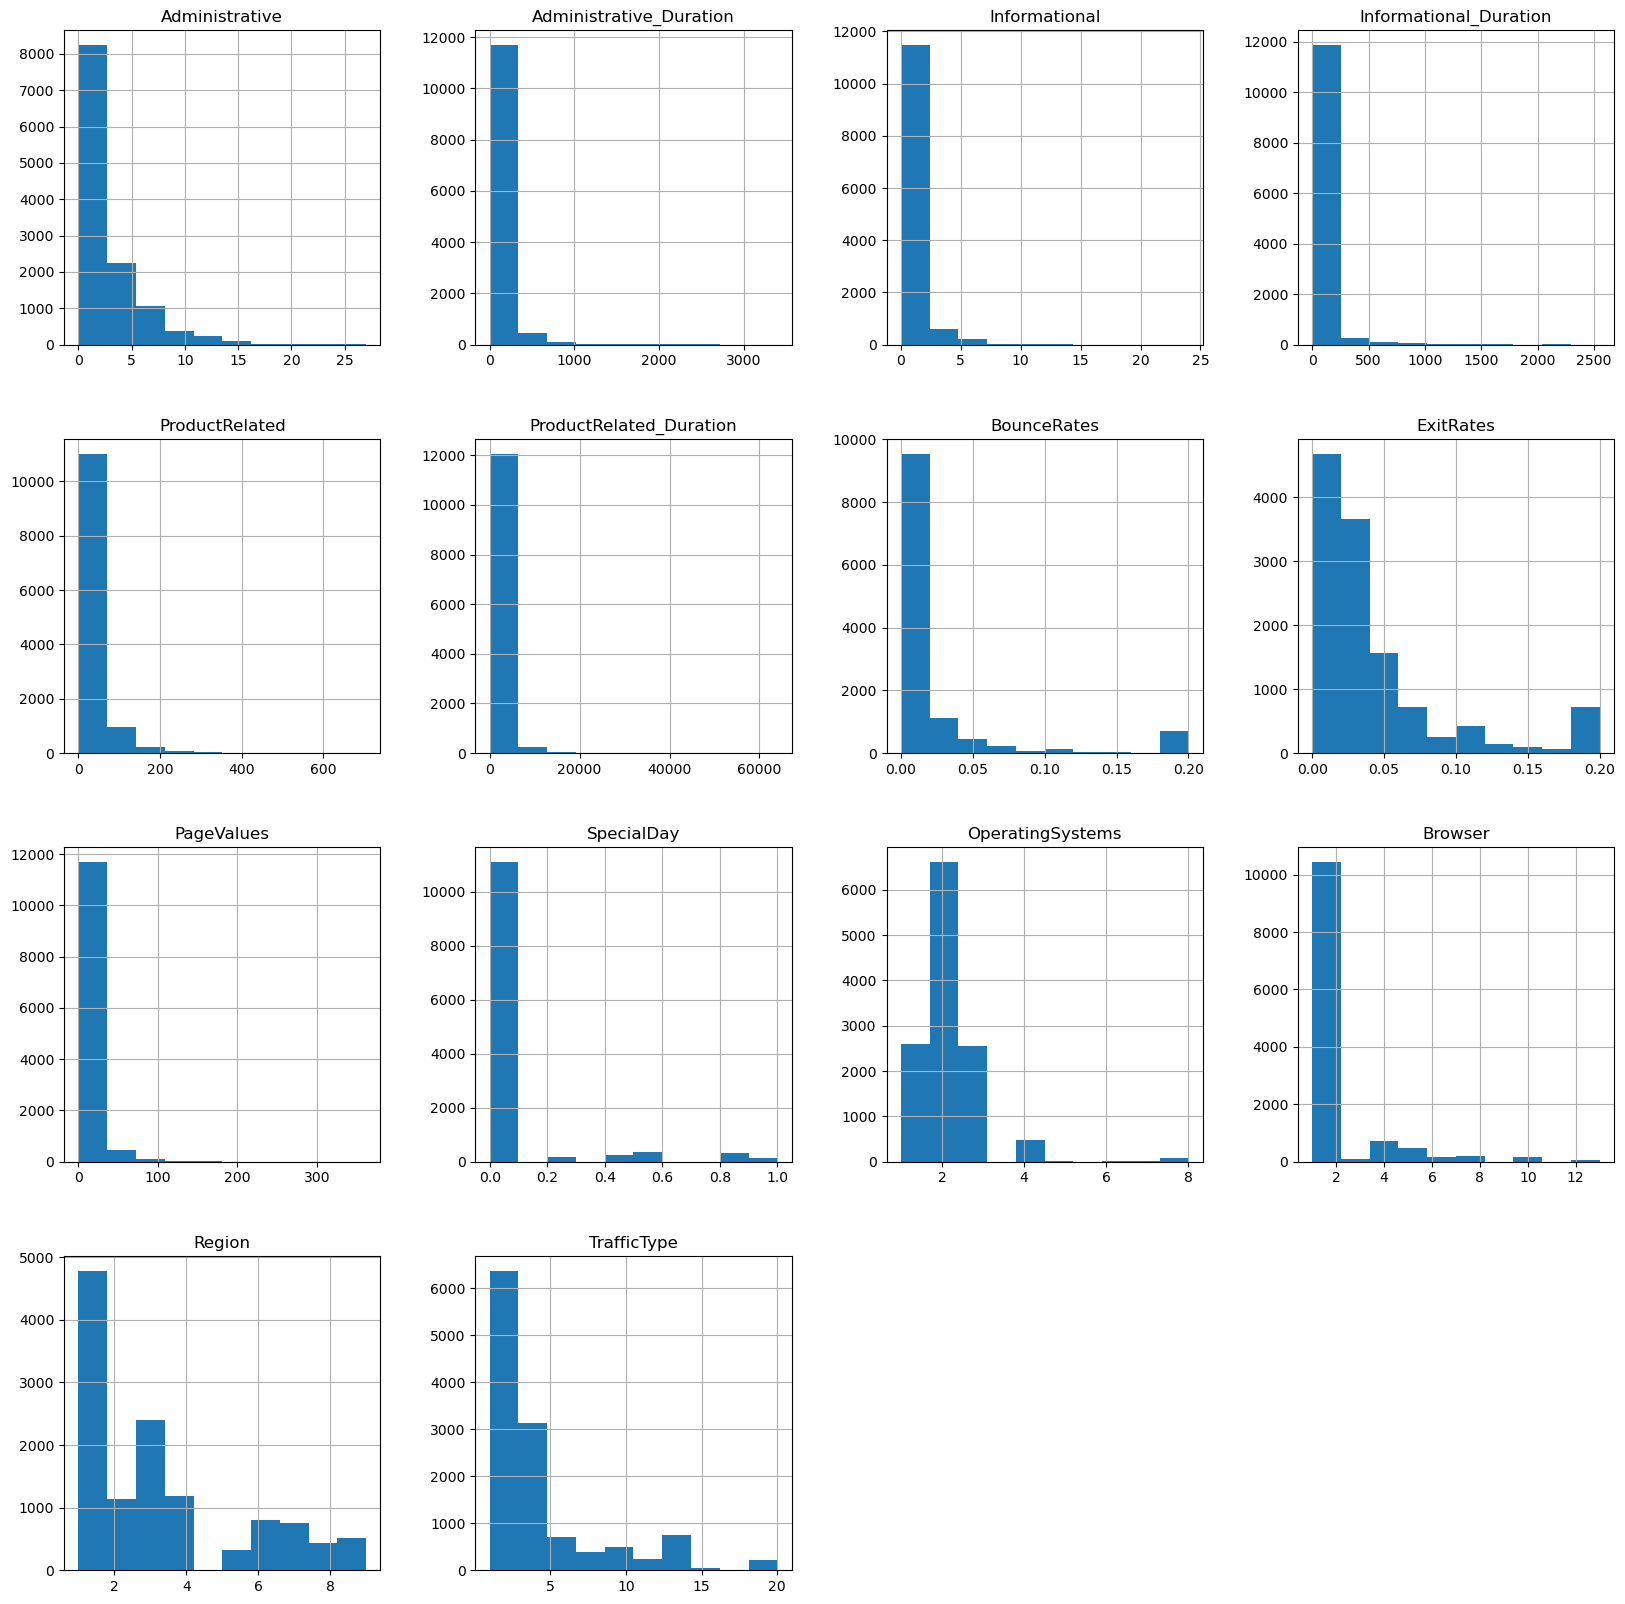

In [ ]:
df.hist(figsize=(20, 20))

<Axes: >

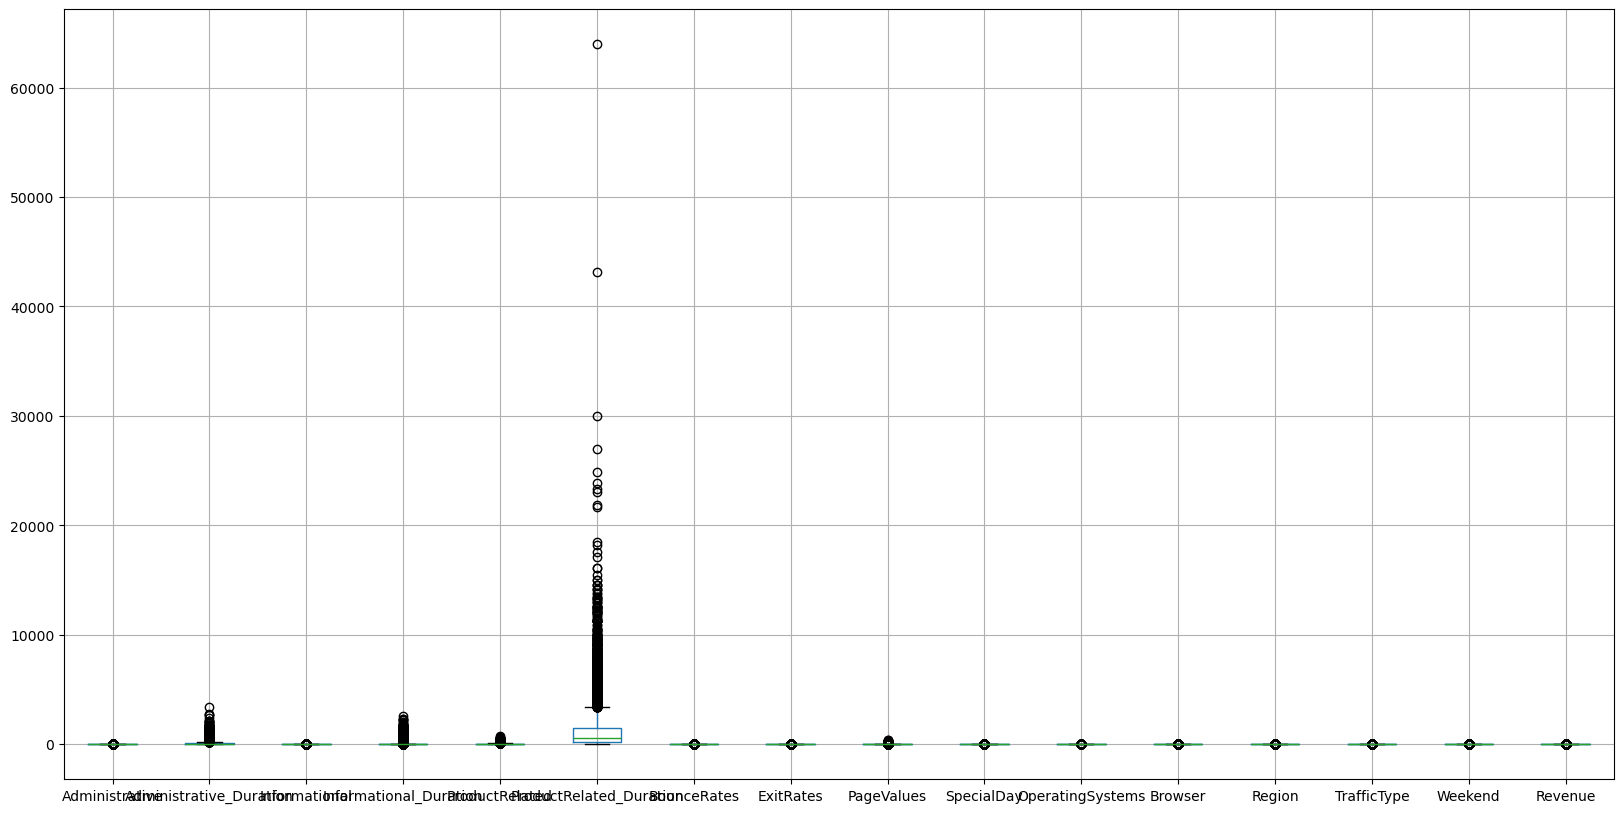

In [ ]:
df.boxplot(figsize=(20, 10))

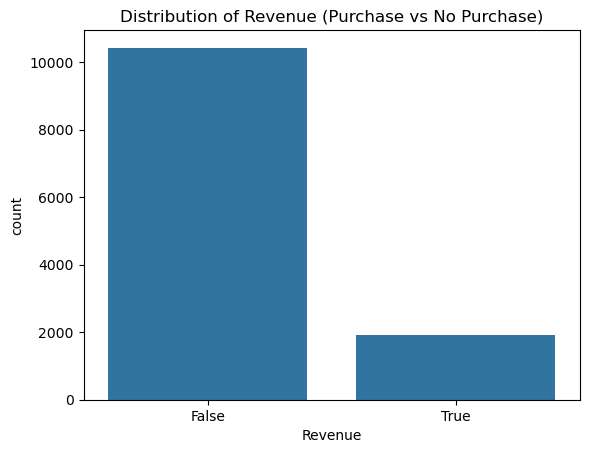

In [ ]:
sns.countplot(x='Revenue', data=df)
plt.title("Distribution of Revenue (Purchase vs No Purchase)")
plt.show()

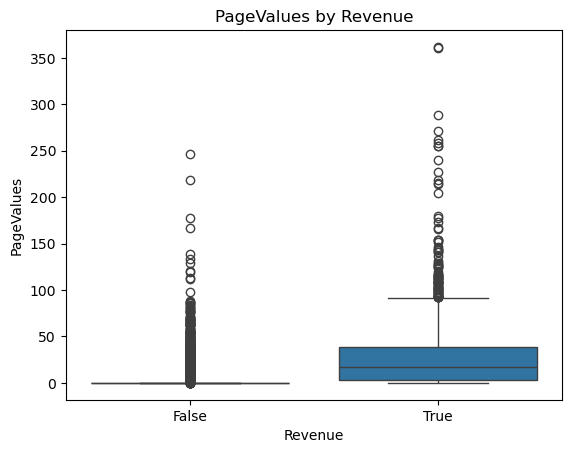

In [ ]:
# Most Important
sns.boxplot(x='Revenue', y='PageValues', data=df)
plt.title("PageValues by Revenue")
plt.show()

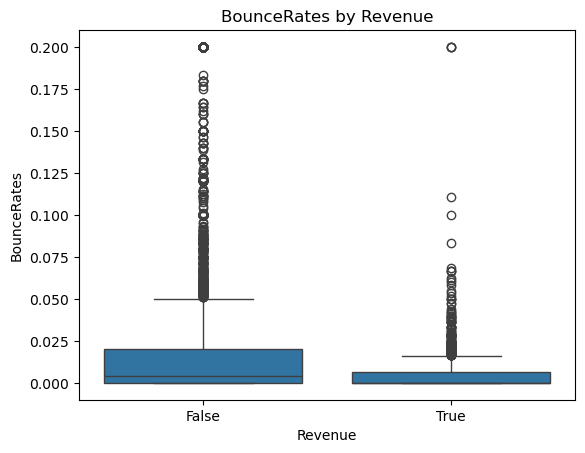

In [ ]:
sns.boxplot(x='Revenue', y='BounceRates', data=df)
plt.title("BounceRates by Revenue")
plt.show()

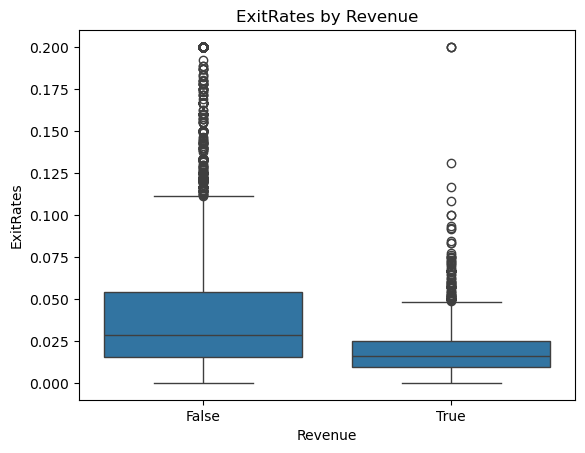

In [ ]:
sns.boxplot(x='Revenue', y='ExitRates', data=df)
plt.title("ExitRates by Revenue")
plt.show()

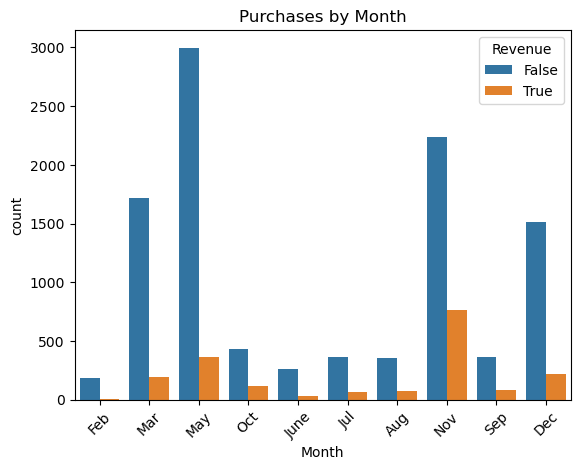

In [29]:
sns.countplot(x='Month', hue='Revenue', data=df)
plt.title("Purchases by Month")
plt.xticks(rotation=45)
plt.show()

In [26]:
# Reload the original dataset (correct path)
df = pd.read_csv('online_shoppers_intention.csv')

print("Original data reloaded successfully!")
print("Shape:", df.shape)

Original data reloaded successfully!
Shape: (12330, 18)


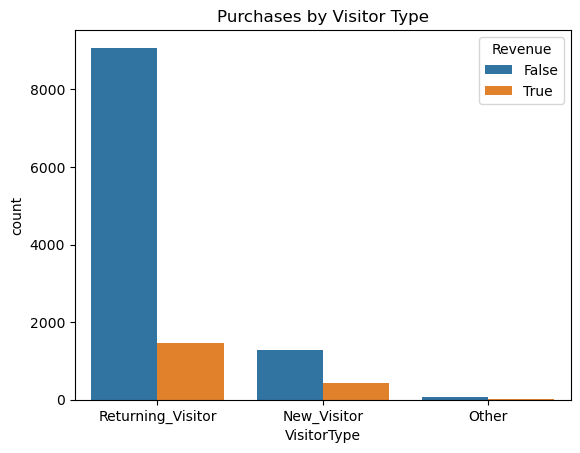

In [16]:
sns.countplot(x='VisitorType', hue='Revenue', data=df)
plt.title("Purchases by Visitor Type")
plt.show()

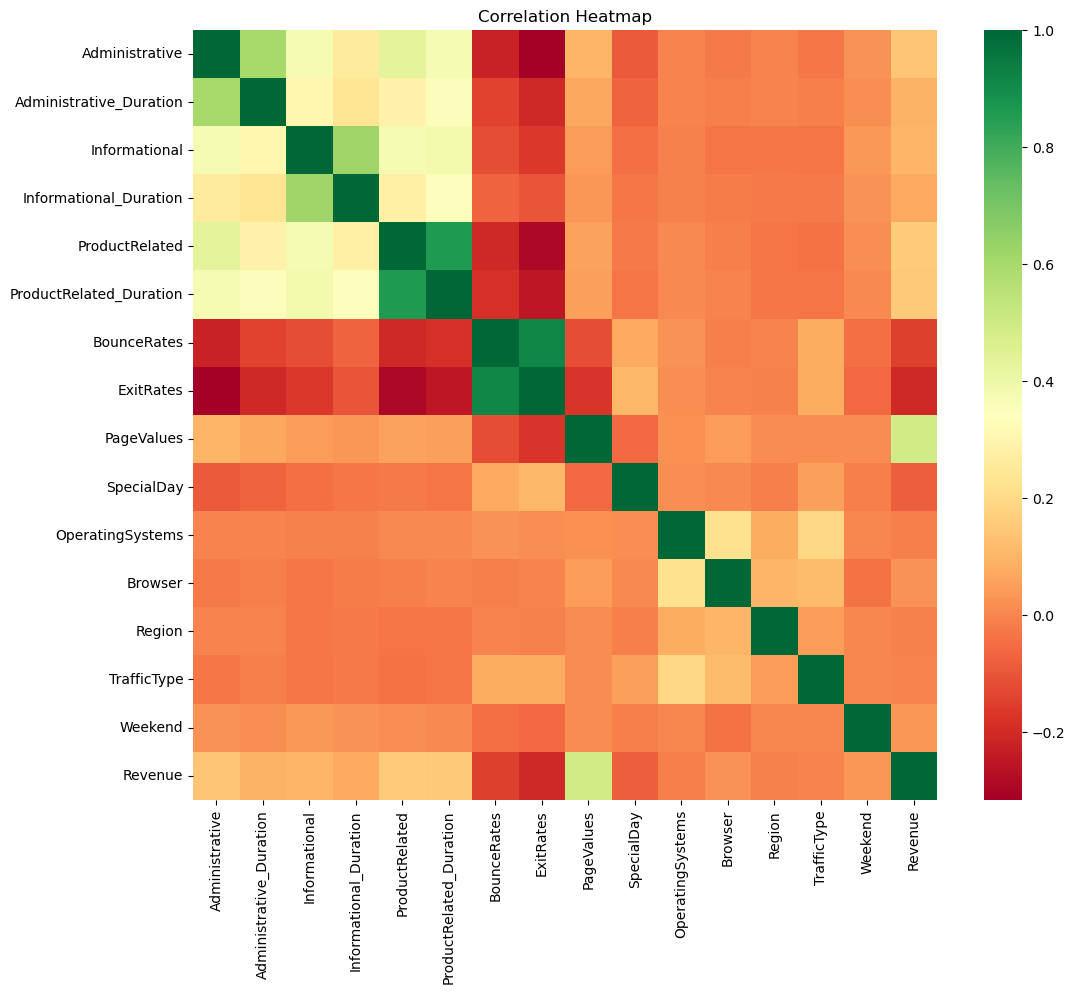

In [18]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='RdYlGn')
plt.title('Correlation Heatmap')
plt.show()

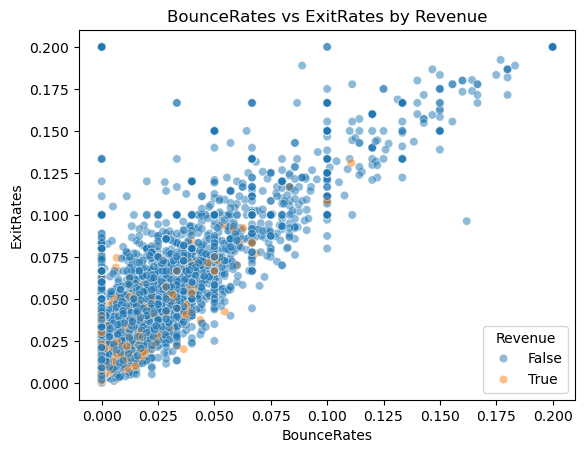

In [30]:
# Example: One useful scatter plot
sns.scatterplot(x='BounceRates', y='ExitRates', hue='Revenue', data=df, alpha=0.5)
plt.title('BounceRates vs ExitRates by Revenue')
plt.show()

In [ ]:
# --- Check and remove duplicates ---
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

In [ ]:
# --- Convert boolean columns to int ---
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

In [ ]:
# --- Encode categorical columns ---
# Month and VisitorType are nominal categories -> one-hot encode
df_encoded = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)
df_encoded.head()

In [ ]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # preserves the ~85/15 class ratio in both sets
    random_state=2026
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))